In [ ]:
# ==========================================
# Step 1.1: 安装必要的第三方库 (仅需运行一次)
# ==========================================
# 安装 PyTorch Geometric (专门处理异构图的 GNN 库)
!pip install torch_geometric

# ==========================================
# Step 1.2: 导入所有核心模块并挂载云盘
# ==========================================
import os
import json
import numpy as np
import random
import math

# 深度学习与张量计算
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

# 图神经网络专区 (PyG)
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as GraphDataLoader
from torch_geometric.nn import HeteroConv, SAGEConv, GATv2Conv

# 网络拓扑与可视化
import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# 强制 Colab 正确渲染 Plotly 3D 图形
pio.renderers.default = 'colab'

# 挂载 Google Drive 以读取你的 96 个数据集
from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# Step 1.3: 全局常数与特征映射字典设定
# ==========================================
DATA_DIR = '/content/drive/MyDrive/260509_dataset'

# 全局模数与体素画布尺寸 (适配最大 35.4m 进深，包含 2 层高度)
VOXEL_SIZE = 300.0
RES_X, RES_Y, RES_Z = 64, 128, 32

# 11 种功能图层映射 (对应 Rhino 建模规范)
CHANNEL_MAP = {
    "empty": 0, "entryway": 1, "living_room": 2, "dining_room": 3,
    "kitchen": 4, "bedroom": 5, "bathroom": 6, "corridor": 7,
    "stairs": 8, "utility": 9, "balcony": 10, "multi_purpose": 11
}
NUM_CHANNELS = len(CHANNEL_MAP)
ID2TYPE = {v: k for k, v in CHANNEL_MAP.items()}

# 可视化色卡 (与你的 Rhino 图层颜色对齐)
COLOR_DICT = {
    1: '#808080', 2: '#FF8000', 3: '#FFFF00', 4: '#00FF00',
    5: '#0000FF', 6: '#FF0000', 7: '#B0B0FF', 8: '#A000FF',
    9: '#3CB371', 10: '#00FFFF', 11: '#FFC0CB'
}

# 设定设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 环境初始化成功！当前使用的设备: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.3 MB/s eta 0:00:00
Mounted at /content/drive
✅ 环境初始化成功！当前使用的设备: cuda


🎲 正在进行 3D 异构抽检，命中模型: house_1728.json


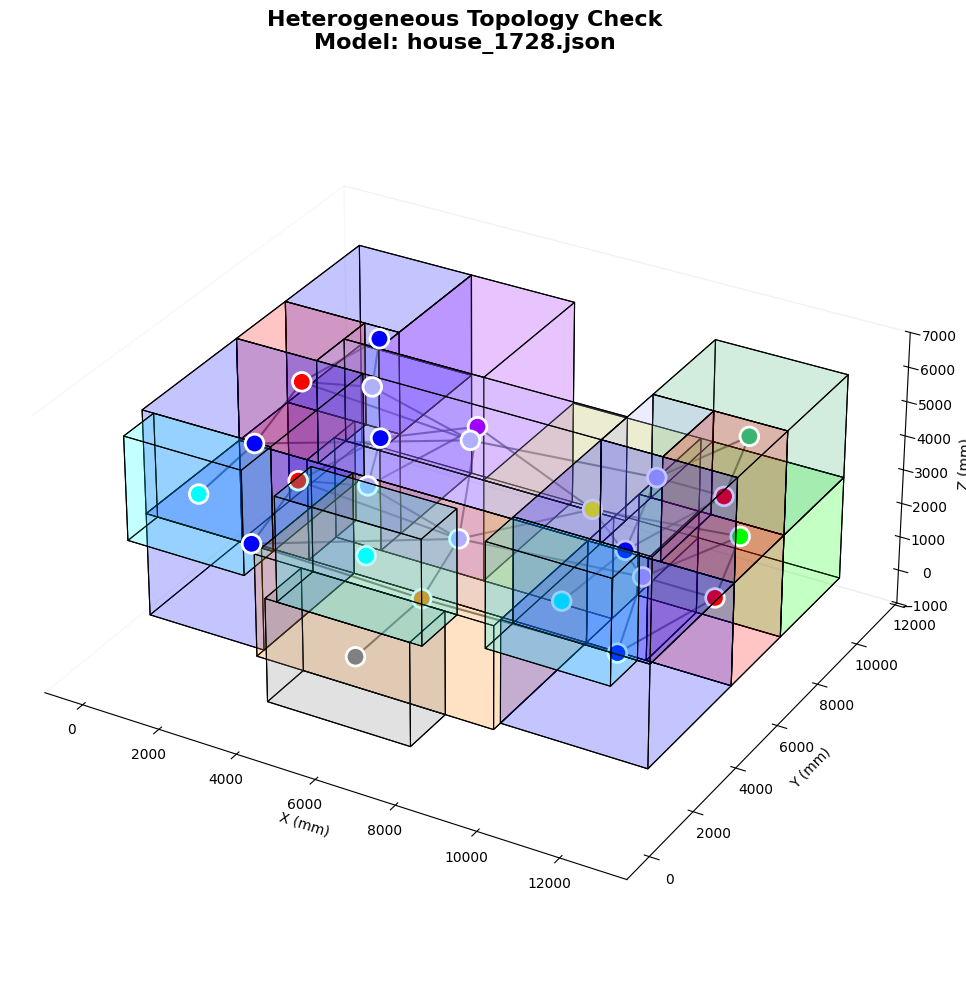

✅ 渲染完成！
📊 节点总数: 25
🔗 同层水平边 (Horizontal): 39 条
🪜 跨层垂直边 (Vertical): 0 条 (应仅出现在楼梯处)


In [ ]:
# ==========================================
# Step 2: 数据集随机抽检 —— 3D物理体块与异构拓扑网络联合可视化
# ==========================================
import os
import json
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 确保路径与第一步一致
DATA_DIR = '/content/drive/MyDrive/260509_dataset'

color_map = {
    'entryway': '#808080',      # 灰色
    'living_room': '#FF8000',   # 橘色
    'dining_room': '#FFFF00',   # 黄色
    'kitchen': '#00FF00',       # 绿色
    'bedroom': '#0000FF',       # 蓝色
    'bathroom': '#FF0000',      # 红色
    'corridor': '#B0B0FF',      # 浅紫色
    'stairs': '#A000FF',        # 紫色
    'utility': '#3CB371',       # 海绿色
    'balcony': '#00FFFF',       # 青色
    'multi_purpose': '#FFC0CB'  # 粉红色
}

# ==========================================
# 异构边检测算法 (严格区分同层与跨层)
# ==========================================
def check_hetero_adjacency(r1, r2, tol=150, min_shared_len=300):
    # 1. 跨层垂直边 (Vertical Edge)：必须不在同一层，且必须有一方是楼梯，且XY平面有重叠
    if r1.get('floor', 1) != r2.get('floor', 1):
        if r1['type'] == 'stairs' or r2['type'] == 'stairs':
            ox = max(0, min(r1['box_max'][0], r2['box_max'][0]) - max(r1['box_min'][0], r2['box_min'][0]))
            oy = max(0, min(r1['box_max'][1], r2['box_max'][1]) - max(r1['box_min'][1], r2['box_min'][1]))
            if ox > 0 and oy > 0:
                return "vertical"
        return None

    # 2. 同层水平边 (Horizontal Edge)：必须在同一层，且存在物理共墙
    if r1.get('floor', 1) == r2.get('floor', 1):
        ox = max(0, min(r1['box_max'][0], r2['box_max'][0]) - max(r1['box_min'][0], r2['box_min'][0]) + tol)
        oy = max(0, min(r1['box_max'][1], r2['box_max'][1]) - max(r1['box_min'][1], r2['box_min'][1]) + tol)

        # 判定共墙：一侧重叠超过300mm，另一侧紧贴(>0)
        if (ox > min_shared_len and oy > 0) or (oy > min_shared_len and ox > 0):
            return "horizontal"

    return None

# ==========================================
# 随机抽取并执行渲染
# ==========================================
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.json') and not f.endswith('_topology.json')]
if not all_files:
    raise ValueError(f"❌ 未在 {DATA_DIR} 找到 JSON 文件！")

sample_file = random.choice(all_files)
print(f"🎲 正在进行 3D 异构抽检，命中模型: {sample_file}")

with open(os.path.join(DATA_DIR, sample_file), 'r', encoding='utf-8') as f:
    data = json.load(f)

rooms = data.get('rooms', [])

# 1. 计算质心并构建异构图
G = nx.Graph()
for r in rooms:
    centroid = [
        (r['box_min'][0] + r['box_max'][0]) / 2,
        (r['box_min'][1] + r['box_max'][1]) / 2,
        (r['box_min'][2] + r['box_max'][2]) / 2
    ]
    r['centroid'] = centroid
    # 节点记录真实楼层，用于后续图神经网络
    G.add_node(r['id'], type=r['type'], centroid=centroid, floor=r.get('floor', 1))

# 2. 提取异构连边
for i in range(len(rooms)):
    for j in range(i + 1, len(rooms)):
        adj_type = check_hetero_adjacency(rooms[i], rooms[j])
        if adj_type:
            G.add_edge(rooms[i]['id'], rooms[j]['id'], relation=adj_type)

# 3. 绘图准备
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

all_min = np.array([r['box_min'] for r in rooms]).min(axis=0)
all_max = np.array([r['box_max'] for r in rooms]).max(axis=0)

size_x = all_max[0] - all_min[0]
size_y = all_max[1] - all_min[1]
size_z = all_max[2] - all_min[2]

# 4. 绘制半透明体块
for r in rooms:
    min_x, min_y, min_z = r['box_min']
    max_x, max_y, max_z = r['box_max']
    vertices = np.array([
        [min_x, min_y, min_z], [max_x, min_y, min_z], [max_x, max_y, min_z], [min_x, max_y, min_z],
        [min_x, min_y, max_z], [max_x, min_y, max_z], [max_x, max_y, max_z], [min_x, max_y, max_z]
    ])
    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]], [vertices[4], vertices[5], vertices[6], vertices[7]],
        [vertices[0], vertices[1], vertices[5], vertices[4]], [vertices[2], vertices[3], vertices[7], vertices[6]],
        [vertices[1], vertices[2], vertices[6], vertices[5]], [vertices[4], vertices[7], vertices[3], vertices[0]]
    ]
    f_color = color_map.get(r['type'], '#BDC3C7')
    # 稍微调低 alpha 增加透明度，让内部的连线更清晰
    poly3d = Poly3DCollection(faces, facecolors=f_color, linewidths=0.8, edgecolors='black', alpha=0.12)
    ax.add_collection3d(poly3d)

# 5. 绘制拓扑节点
xs = [n[1]['centroid'][0] for n in G.nodes(data=True)]
ys = [n[1]['centroid'][1] for n in G.nodes(data=True)]
zs = [n[1]['centroid'][2] for n in G.nodes(data=True)]
cs = [color_map.get(n[1]['type'], 'gray') for n in G.nodes(data=True)]

ax.scatter(xs, ys, zs, s=180, c=cs, depthshade=False, edgecolors='white', linewidths=2, alpha=1.0)

# 6. 绘制异构拓扑边
horizontal_count = 0
vertical_count = 0
for u, v, d in G.edges(data=True):
    lx = [G.nodes[u]['centroid'][0], G.nodes[v]['centroid'][0]]
    ly = [G.nodes[u]['centroid'][1], G.nodes[v]['centroid'][1]]
    lz = [G.nodes[u]['centroid'][2], G.nodes[v]['centroid'][2]]

    if d['relation'] == 'vertical':
        # 垂直跨层边：红色加粗虚线，极具视觉冲击力
        ax.plot(lx, ly, lz, c='#FF0000', linewidth=3, linestyle='--')
        vertical_count += 1
    else:
        # 水平共墙边：深灰色实线
        ax.plot(lx, ly, lz, c='#2C3E50', linewidth=1.5, alpha=0.7)
        horizontal_count += 1

# 7. 画面自适应与排版
ax.set_box_aspect((size_x, size_y, size_z))
ax.set_title(f"Heterogeneous Topology Check\nModel: {sample_file}", fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('X (mm)'), ax.set_ylabel('Y (mm)'), ax.set_zlabel('Z (mm)')

padding = 1000
ax.set_xlim(all_min[0]-padding, all_max[0]+padding)
ax.set_ylim(all_min[1]-padding, all_max[1]+padding)
ax.set_zlim(all_min[2]-padding, all_max[2]+padding)

# 去除多余的网格背景，使建筑体量更突出
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()
plt.show()

print(f"✅ 渲染完成！")
print(f"📊 节点总数: {len(G.nodes)}")
print(f"🔗 同层水平边 (Horizontal): {horizontal_count} 条")
print(f"🪜 跨层垂直边 (Vertical): {vertical_count} 条 (应仅出现在楼梯处)")

In [ ]:
# ==========================================
# Step 2 (升级版): 完美解决透明着色丢失问题
# 三维物理体块 + 异构图拓扑网络 的 WebGL 同空间融合渲染
# ==========================================
import os
import json
import random
import numpy as np
import networkx as nx
import plotly.graph_objects as go

# 强制 Colab 正确渲染 Plotly
import plotly.io as pio
pio.renderers.default = 'colab'

DATA_DIR = '/content/drive/MyDrive/260509_dataset'

color_map = {
    'entryway': '#808080', 'living_room': '#FF8000', 'dining_room': '#FFFF00',
    'kitchen': '#00FF00', 'bedroom': '#0000FF', 'bathroom': '#FF0000',
    'corridor': '#B0B0FF', 'stairs': '#A000FF', 'utility': '#3CB371',
    'balcony': '#00FFFF', 'multi_purpose': '#FFC0CB'
}

NAME_MAP = {
    "entryway": "玄关", "living_room": "客厅", "dining_room": "餐厅",
    "kitchen": "厨房", "bedroom": "卧室", "bathroom": "卫生间",
    "corridor": "过道", "stairs": "楼梯", "utility": "储藏",
    "balcony": "阳台", "multi_purpose": "多功能"
}

# ==========================================
# 异构边检测算法
# ==========================================
def check_hetero_adjacency(r1, r2, tol=150, min_shared_len=300):
    if r1.get('floor', 1) != r2.get('floor', 1):
        if r1['type'] == 'stairs' or r2['type'] == 'stairs':
            ox = max(0, min(r1['box_max'][0], r2['box_max'][0]) - max(r1['box_min'][0], r2['box_min'][0]))
            oy = max(0, min(r1['box_max'][1], r2['box_max'][1]) - max(r1['box_min'][1], r2['box_min'][1]))
            if ox > 0 and oy > 0: return "vertical"
        return None

    if r1.get('floor', 1) == r2.get('floor', 1):
        ox = max(0, min(r1['box_max'][0], r2['box_max'][0]) - max(r1['box_min'][0], r2['box_min'][0]) + tol)
        oy = max(0, min(r1['box_max'][1], r2['box_max'][1]) - max(r1['box_min'][1], r2['box_min'][1]) + tol)
        if (ox > min_shared_len and oy > 0) or (oy > min_shared_len and ox > 0): return "horizontal"
    return None

# ==========================================
# 数据加载与图构建
# ==========================================
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.json') and not f.endswith('_topology.json')]
sample_file = random.choice(all_files)
print(f"🎲 抽检模型: {sample_file}")

with open(os.path.join(DATA_DIR, sample_file), 'r', encoding='utf-8') as f:
    data = json.load(f)

rooms = data.get('rooms', [])
G = nx.Graph()

for r in rooms:
    centroid = [
        (r['box_min'][0] + r['box_max'][0]) / 2,
        (r['box_min'][1] + r['box_max'][1]) / 2,
        (r['box_min'][2] + r['box_max'][2]) / 2
    ]
    r['centroid'] = centroid
    G.add_node(r['id'], type=r['type'], centroid=centroid, floor=r.get('floor', 1))

for i in range(len(rooms)):
    for j in range(i + 1, len(rooms)):
        adj_type = check_hetero_adjacency(rooms[i], rooms[j])
        if adj_type:
            G.add_edge(rooms[i]['id'], rooms[j]['id'], relation=adj_type)

# ==========================================
# WebGL 高保真 3D 渲染 (Plotly)
# ==========================================
fig = go.Figure()

all_min = np.array([r['box_min'] for r in rooms]).min(axis=0)
all_max = np.array([r['box_max'] for r in rooms]).max(axis=0)

# 1. 绘制半透明 3D 建筑体块
for r in rooms:
    xmin, ymin, zmin = r['box_min']
    xmax, ymax, zmax = r['box_max']
    color = color_map.get(r['type'], '#CCCCCC')

    # 构造 Plotly Box 的面
    x = [xmin, xmax, xmax, xmin, xmin, xmax, xmax, xmin]
    y = [ymin, ymin, ymax, ymax, ymin, ymin, ymax, ymax]
    z = [zmin, zmin, zmin, zmin, zmax, zmax, zmax, zmax]
    i, j, k = [7,0,0,0,4,4,6,6,4,0,3,2], [3,4,1,2,5,6,5,2,0,1,6,3], [0,7,2,3,6,7,1,1,5,5,7,6]

    # 注入体块，透明度设为 0.25 保证色彩饱满且能看清内部连线
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z, i=i, j=j, k=k,
        color=color, opacity=0.25,
        name=NAME_MAP.get(r['type'], r['type']),
        hoverinfo='text',
        text=f"【{NAME_MAP.get(r['type'], r['type'])}】 F{r.get('floor', 1)}"
    ))

    # 绘制体块黑边框
    ex = [xmin, xmax, xmax, xmin, xmin, None, xmin, xmax, xmax, xmin, xmin, None, xmin, xmin, None, xmax, xmax, None, xmax, xmax, None, xmin, xmin]
    ey = [ymin, ymin, ymax, ymax, ymin, None, ymin, ymin, ymax, ymax, ymin, None, ymin, ymin, None, ymin, ymin, None, ymax, ymax, None, ymax, ymax]
    ez = [zmin, zmin, zmin, zmin, zmin, None, zmax, zmax, zmax, zmax, zmax, None, zmin, zmax, None, zmin, zmax, None, zmin, zmax, None, zmin, zmax]
    fig.add_trace(go.Scatter3d(x=ex, y=ey, z=ez, mode='lines', line=dict(color='black', width=2), showlegend=False, hoverinfo='skip'))

# 2. 绘制拓扑节点 (悬浮在每个体块的质心)
node_x = [n[1]['centroid'][0] for n in G.nodes(data=True)]
node_y = [n[1]['centroid'][1] for n in G.nodes(data=True)]
node_z = [n[1]['centroid'][2] for n in G.nodes(data=True)]
node_colors = [color_map.get(n[1]['type'], 'gray') for n in G.nodes(data=True)]

fig.add_trace(go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers',
    marker=dict(size=12, color=node_colors, line=dict(width=2, color='white')),
    showlegend=False, hoverinfo='skip'
))

# 3. 绘制异构拓扑连边
edge_hx, edge_hy, edge_hz = [], [], []
edge_vx, edge_vy, edge_vz = [], [], []

for u, v, d in G.edges(data=True):
    c_u, c_v = G.nodes[u]['centroid'], G.nodes[v]['centroid']
    if d['relation'] == 'vertical':
        edge_vx.extend([c_u[0], c_v[0], None])
        edge_vy.extend([c_u[1], c_v[1], None])
        edge_vz.extend([c_u[2], c_v[2], None])
    else:
        edge_hx.extend([c_u[0], c_v[0], None])
        edge_hy.extend([c_u[1], c_v[1], None])
        edge_hz.extend([c_u[2], c_v[2], None])

# 添加水平共墙边 (深灰色线条)
fig.add_trace(go.Scatter3d(
    x=edge_hx, y=edge_hy, z=edge_hz, mode='lines',
    line=dict(color='#555555', width=4), name='水平共墙拓扑 (Horizontal)', hoverinfo='none'
))

# 添加垂直跨层边 (醒目红色粗线)
fig.add_trace(go.Scatter3d(
    x=edge_vx, y=edge_vy, z=edge_vz, mode='lines',
    line=dict(color='#FF0000', width=8), name='垂直跨层拓扑 (Vertical)', hoverinfo='none'
))

# ==========================================
# 场景自适应排版
# ==========================================
fig.update_layout(
    title=f"3D 物理体块与异构图网络 同空间渲染 (Model: {sample_file})",
    height=800, width=1200, margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        xaxis=dict(title='X (mm)', range=[all_min[0]-500, all_max[0]+500], showbackground=False),
        yaxis=dict(title='Y (mm)', range=[all_min[1]-500, all_max[1]+500], showbackground=False),
        zaxis=dict(title='Z (mm)', range=[all_min[2]-500, all_max[2]+500], showbackground=False),
        aspectmode='data' # 核心：锁定真实长宽高物理比例
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

🎲 抽检模型: house_1898.json


In [ ]:
# ==========================================
# Step 2: 批量生成异构图特征与 3D 体素标签
# 核心作用：将 JSON 转化为 PyTorch 专属的 HeteroData 和 Voxel 张量
# ==========================================
import os
import json
import torch
import numpy as np
from torch_geometric.data import HeteroData

# 1. 路径与参数设定
DATA_DIR = '/content/drive/MyDrive/260509_dataset'
OUT_DIR = os.path.join(DATA_DIR, 'processed_tensors')
if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

VOXEL_SIZE = 300.0
RES_X, RES_Y, RES_Z = 64, 128, 32

CHANNEL_MAP = {
    "empty": 0, "entryway": 1, "living_room": 2, "dining_room": 3,
    "kitchen": 4, "bedroom": 5, "bathroom": 6, "corridor": 7,
    "stairs": 8, "utility": 9, "balcony": 10, "multi_purpose": 11
}
NUM_CHANNELS = len(CHANNEL_MAP)

# 2. 异构类型分类器
def get_node_type(room_type):
    if room_type in ['bedroom', 'living_room', 'dining_room', 'multi_purpose']:
        return "living"
    elif room_type in ['kitchen', 'bathroom', 'utility', 'balcony']:
        return "service"
    else: # corridor, stairs, entryway
        return "circulation"

# 3. 边检测器 (与可视化逻辑一致)
def check_hetero_adjacency(r1, r2, tol=150, min_shared_len=300):
    if r1.get('floor', 1) != r2.get('floor', 1):
        if r1['type'] == 'stairs' or r2['type'] == 'stairs':
            ox = max(0, min(r1['box_max'][0], r2['box_max'][0]) - max(r1['box_min'][0], r2['box_min'][0]))
            oy = max(0, min(r1['box_max'][1], r2['box_max'][1]) - max(r1['box_min'][1], r2['box_min'][1]))
            if ox > 0 and oy > 0: return "vertical"
        return None

    if r1.get('floor', 1) == r2.get('floor', 1):
        ox = max(0, min(r1['box_max'][0], r2['box_max'][0]) - max(r1['box_min'][0], r2['box_min'][0]) + tol)
        oy = max(0, min(r1['box_max'][1], r2['box_max'][1]) - max(r1['box_min'][1], r2['box_min'][1]) + tol)
        if (ox > min_shared_len and oy > 0) or (oy > min_shared_len and ox > 0): return "horizontal"
    return None

# ==========================================
# 4. 核心处理循环
# ==========================================
valid_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.json') and not f.endswith('_topology.json')]
print(f"⚙️ 开始处理 {len(valid_files)} 个户型数据...")

processed_count = 0
for file in valid_files:
    try:
        with open(os.path.join(DATA_DIR, file), 'r', encoding='utf-8') as f:
            data = json.load(f)

        rooms = data.get('rooms', [])
        if not rooms: continue

        all_coords = np.array([r['box_min'] for r in rooms] + [r['box_max'] for r in rooms])
        build_min = all_coords.min(axis=0)
        build_max = all_coords.max(axis=0)
        b_size = build_max - build_min

        # ------------------------------------
        # 任务 A：提取 HeteroData (异构图)
        # ------------------------------------
        hetero_graph = HeteroData()
        nodes_dict = {"living": [], "service": [], "circulation": []}
        id_to_idx = {}

        for r in rooms:
            dx = r['box_max'][0] - r['box_min'][0]
            dy = r['box_max'][1] - r['box_min'][1]
            area = (dx * dy) / 1e6
            aspect = max(dx, dy) / min(dx, dy) if min(dx, dy) > 0 else 1.0

            centroid_x = ((r['box_min'][0] + r['box_max'][0]) / 2 - build_min[0]) / (b_size[0] + 1e-5)
            centroid_y = ((r['box_min'][1] + r['box_max'][1]) / 2 - build_min[1]) / (b_size[1] + 1e-5)
            centroid_z = ((r['box_min'][2] + r['box_max'][2]) / 2 - build_min[2]) / (b_size[2] + 1e-5)

            feat = [area, aspect, centroid_x, centroid_y, centroid_z]
            ntype = get_node_type(r['type'])

            id_to_idx[r['id']] = (ntype, len(nodes_dict[ntype]))
            nodes_dict[ntype].append(feat)

        for ntype, feats in nodes_dict.items():
            if feats:
                hetero_graph[ntype].x = torch.tensor(feats, dtype=torch.float32)
            else:
                hetero_graph[ntype].x = torch.empty((0, 5), dtype=torch.float32)

        edges_dict = {}
        for i in range(len(rooms)):
            for j in range(i + 1, len(rooms)):
                r1, r2 = rooms[i], rooms[j]
                t1, idx1 = id_to_idx[r1['id']]
                t2, idx2 = id_to_idx[r2['id']]

                rel = check_hetero_adjacency(r1, r2)
                if rel:
                    edge_key = (t1, rel, t2)
                    edge_key_rev = (t2, rel, t1)
                    if edge_key not in edges_dict: edges_dict[edge_key] = []
                    if edge_key_rev not in edges_dict: edges_dict[edge_key_rev] = []

                    edges_dict[edge_key].append([idx1, idx2])
                    edges_dict[edge_key_rev].append([idx2, idx1])

        for e_key, e_list in edges_dict.items():
            hetero_graph[e_key].edge_index = torch.tensor(e_list, dtype=torch.long).t().contiguous()

        # ------------------------------------
        # 任务 B：生成 3D 体素张量 (防穿插)
        # ------------------------------------
        grid_indices = np.zeros((RES_X, RES_Y, RES_Z), dtype=np.int8)
        phys_center_xy = (build_min[:2] + build_max[:2]) / 2.0
        offset_xy = np.array([RES_X * VOXEL_SIZE / 2, RES_Y * VOXEL_SIZE / 2]) - phys_center_xy
        z_min_phys = build_min[2]

        for r in rooms:
            ch_idx = CHANNEL_MAP.get(r['type'], 0)
            ix_min = int((r['box_min'][0] + offset_xy[0]) / VOXEL_SIZE)
            ix_max = int((r['box_max'][0] + offset_xy[0]) / VOXEL_SIZE)
            iy_min = int((r['box_min'][1] + offset_xy[1]) / VOXEL_SIZE)
            iy_max = int((r['box_max'][1] + offset_xy[1]) / VOXEL_SIZE)
            iz_min = int((r['box_min'][2] - z_min_phys) / VOXEL_SIZE)
            iz_max = int((r['box_max'][2] - z_min_phys) / VOXEL_SIZE)

            grid_indices[max(0, ix_min):min(RES_X, ix_max),
                         max(0, iy_min):min(RES_Y, iy_max),
                         max(0, iz_min):min(RES_Z, iz_max)] = ch_idx

        one_hot = np.zeros((NUM_CHANNELS, RES_X, RES_Y, RES_Z), dtype=np.float32)
        for c in range(NUM_CHANNELS):
            one_hot[c, :, :, :] = (grid_indices == c).astype(np.float32)

        voxel_tensor = torch.tensor(one_hot, dtype=torch.float32)

        # ------------------------------------
        # 任务 C：保存打包为 .pt 文件
        # ------------------------------------
        save_data = {
            'graph': hetero_graph,
            'voxel': voxel_tensor
        }

        save_name = file.replace('.json', '.pt')
        torch.save(save_data, os.path.join(OUT_DIR, save_name))
        processed_count += 1

    except Exception as e:
        print(f"⚠️ 处理文件 {file} 时出错: {e}")

print(f"\n🎉 预处理完毕！成功生成 {processed_count} 个深度学习标准特征对，已保存在 {OUT_DIR}。")

⚙️ 开始处理 96 个户型数据...

🎉 预处理完毕！成功生成 96 个深度学习标准特征对，已保存在 /content/drive/MyDrive/260509_dataset/processed_tensors。


In [ ]:
# ==========================================
# 真正定义的 Step 3: 核心深度学习模型架构 (已修复自环 Bug)
# 异构图空间编码器 (Hetero-Encoder) + 3D 体素解码器 (3D CNN Decoder)
# ==========================================
import torch
import torch.nn as nn
import numpy as np
from torch_geometric.nn import HeteroConv, SAGEConv, GATv2Conv, global_mean_pool

# ==========================================
# 模块 A: 异构图空间模态编码器 (Hetero-Encoder)
# ==========================================
class HeteroArchitectureEncoder(nn.Module):
    def __init__(self, node_in_dim=5, hidden_dim=128, latent_dim=256):
        super().__init__()

        # 1. 异构图卷积层 1
        self.conv1 = HeteroConv({
            # 水平共墙边 (Horizontal)：使用 GraphSAGE 提取相邻特征
            ('living', 'horizontal', 'living'): SAGEConv(node_in_dim, hidden_dim),
            ('living', 'horizontal', 'service'): SAGEConv(node_in_dim, hidden_dim),
            ('service', 'horizontal', 'living'): SAGEConv(node_in_dim, hidden_dim),
            ('service', 'horizontal', 'service'): SAGEConv(node_in_dim, hidden_dim),
            ('living', 'horizontal', 'circulation'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'horizontal', 'living'): SAGEConv(node_in_dim, hidden_dim),
            ('service', 'horizontal', 'circulation'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'horizontal', 'service'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'horizontal', 'circulation'): SAGEConv(node_in_dim, hidden_dim),

            # 垂直跨层边 (Vertical)：使用 GATv2，必须设置 add_self_loops=False 以兼容异构边
            ('circulation', 'vertical', 'living'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('living', 'vertical', 'circulation'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('circulation', 'vertical', 'service'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('service', 'vertical', 'circulation'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('circulation', 'vertical', 'circulation'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
        }, aggr='sum')

        # 2. 异构图卷积层 2 (进一步提取深层抽象特征)
        self.conv2 = HeteroConv({
            ('living', 'horizontal', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('living', 'horizontal', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'horizontal', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'horizontal', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('living', 'horizontal', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'horizontal', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'horizontal', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'horizontal', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'horizontal', 'circulation'): SAGEConv(hidden_dim, latent_dim),

            # 第二层依然可以沿用 SAGEConv，它自身机制不需要改 add_self_loops
            ('circulation', 'vertical', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('living', 'vertical', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'vertical', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'vertical', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'vertical', 'circulation'): SAGEConv(hidden_dim, latent_dim),
        }, aggr='sum')

    def forward(self, x_dict, edge_index_dict, batch_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}

        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}

        pooled_feats = []
        for ntype, x in x_dict.items():
            if ntype in batch_dict and x.size(0) > 0:
                pooled = global_mean_pool(x, batch_dict[ntype])
                pooled_feats.append(pooled)

        if not pooled_feats:
            return torch.zeros((1, 256), device=x_dict[list(x_dict.keys())[0]].device)

        global_z = sum(pooled_feats) / len(pooled_feats)
        return global_z

# ==========================================
# 模块 B: 三维物理体素解码器 (3D CNN Decoder)
# ==========================================
class VoxelDecoder(nn.Module):
    def __init__(self, latent_dim=256, channels=12):
        super().__init__()
        self.init_volume_size = (256, 4, 8, 2)
        self.fc = nn.Linear(latent_dim, int(np.prod(self.init_volume_size)))

        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(32, channels, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, z):
        batch_size = z.size(0)
        d = self.fc(z).view(batch_size, *self.init_volume_size)
        out_voxel = self.decoder(d)
        return out_voxel

# ==========================================
# 模块 C: 完整生成管线集成
# ==========================================
class HeteroArchitectureGenerator(nn.Module):
    def __init__(self, node_in_dim=5, hidden_dim=128, latent_dim=256, channels=12):
        super().__init__()
        self.encoder = HeteroArchitectureEncoder(node_in_dim, hidden_dim, latent_dim)
        self.decoder = VoxelDecoder(latent_dim, channels)

    def forward(self, hetero_data):
        z = self.encoder(hetero_data.x_dict, hetero_data.edge_index_dict, hetero_data.batch_dict)
        out_voxel = self.decoder(z)
        return out_voxel

# 实例化模型并挂载至设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HeteroArchitectureGenerator().to(device)

print("✅ HeteroGNN + 3D CNN 联合架构已成功定义，自环Bug已修复，并挂载至显存！")
total_params = sum(p.numel() for p in model.parameters())
print(f"📊 模型总参数量: {total_params:,}")

✅ HeteroGNN + 3D CNN 联合架构已成功定义，自环Bug已修复，并挂载至显存！
📊 模型总参数量: 7,939,500


📂 正在加载数据集入内存...
✅ 成功加载 96 个样本！

🚀 开始在 cuda 上执行训练...
Epoch [001/200] | Loss: 0.2110 | Voxel Acc: 98.23%
Epoch [010/200] | Loss: 0.0503 | Voxel Acc: 97.58%
Epoch [020/200] | Loss: 0.0455 | Voxel Acc: 98.63%
Epoch [030/200] | Loss: 0.0424 | Voxel Acc: 98.78%
Epoch [040/200] | Loss: 0.0374 | Voxel Acc: 98.42%
Epoch [050/200] | Loss: 0.0317 | Voxel Acc: 98.89%
Epoch [060/200] | Loss: 0.0204 | Voxel Acc: 98.97%
Epoch [070/200] | Loss: 0.0130 | Voxel Acc: 99.54%
Epoch [080/200] | Loss: 0.0096 | Voxel Acc: 99.67%
Epoch [090/200] | Loss: 0.0057 | Voxel Acc: 99.89%
Epoch [100/200] | Loss: 0.0046 | Voxel Acc: 99.82%
Epoch [110/200] | Loss: 0.0023 | Voxel Acc: 99.91%
Epoch [120/200] | Loss: 0.0033 | Voxel Acc: 99.94%
Epoch [130/200] | Loss: 0.0019 | Voxel Acc: 99.96%
Epoch [140/200] | Loss: 0.0022 | Voxel Acc: 99.90%
Epoch [150/200] | Loss: 0.0015 | Voxel Acc: 99.94%
Epoch [160/200] | Loss: 0.0007 | Voxel Acc: 99.99%
Epoch [170/200] | Loss: 0.0007 | Voxel Acc: 99.98%
Epoch [180/200] | Loss: 0.0014

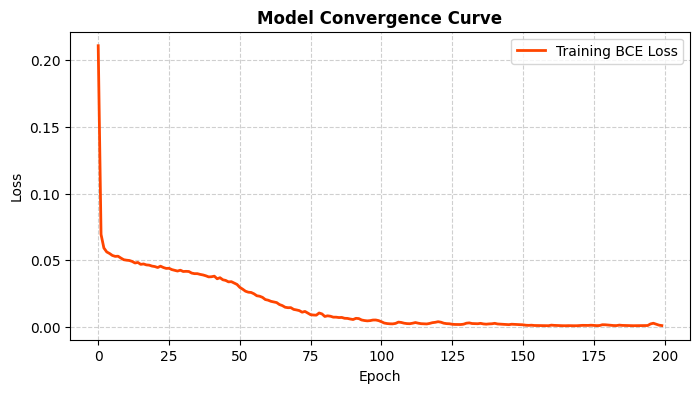

In [ ]:
# ==========================================
# Step 4: 启动 HeteroGNN + 3D CNN 联合训练 (已修复 PyTorch 2.6 安全拦截问题)
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.loader import DataLoader as GraphDataLoader

# 1. 挂载之前预处理好的特征张量路径
DATA_DIR = '/content/drive/MyDrive/260509_dataset'
TENSORS_DIR = os.path.join(DATA_DIR, 'processed_tensors')
RES_X, RES_Y, RES_Z = 64, 128, 32
NUM_CHANNELS = 12

print("📂 正在加载数据集入内存...")
dataset_list = []
tensor_files = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]

for file in tensor_files:
    try:
        # 💡【核心修复】：明确设定 weights_only=False，允许加载 PyG 异构图对象
        data_dict = torch.load(os.path.join(TENSORS_DIR, file), weights_only=False)
        hg = data_dict['graph']

        # 将真实的体素(标准答案)直接挂载到图对象上
        hg.y = data_dict['voxel']
        dataset_list.append(hg)
    except Exception as e:
        print(f"读取 {file} 失败: {e}")

print(f"✅ 成功加载 {len(dataset_list)} 个样本！")

# 2. 构建数据加载器 (针对 T4 GPU，batch_size 设为 2 防爆显存)
BATCH_SIZE = 2
train_loader = GraphDataLoader(dataset_list, batch_size=BATCH_SIZE, shuffle=True)

# 3. 定义损失函数与优化器
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

EPOCHS = 200
print(f"\n🚀 开始在 {device} 上执行训练...")

loss_history = []
model.train()

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0

    for batch_data in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()

        # 模型前向推演
        pred_voxel_logits = model(batch_data)

        # PyG 拼接降维修复：还原为 [Batch, Channels, X, Y, Z]
        actual_batch_size = batch_data.num_graphs
        target_voxel = batch_data.y.view(actual_batch_size, NUM_CHANNELS, RES_X, RES_Y, RES_Z)

        # 计算 Loss 并反向传播
        loss = criterion(pred_voxel_logits, target_voxel)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * actual_batch_size

    scheduler.step()
    avg_loss = epoch_loss / len(dataset_list)
    loss_history.append(avg_loss)

    # 打印进度
    if epoch % 10 == 0 or epoch == 1:
        preds = (torch.sigmoid(pred_voxel_logits) > 0.5).float()
        acc = (preds == target_voxel).float().mean()
        print(f"Epoch [{epoch:03d}/{EPOCHS}] | Loss: {avg_loss:.4f} | Voxel Acc: {acc.item() * 100:.2f}%")

# 4. 保存模型权重
save_path = os.path.join(DATA_DIR, 'hetero_3dcnn_best.pth')
torch.save(model.state_dict(), save_path)
print(f"\n🎉 训练圆满完成！模型大脑(权重)已安全保存至: {save_path}")

# 5. 绘制 Loss 收敛曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='Training BCE Loss', color='#FF4500', linewidth=2)
plt.title("Model Convergence Curve", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 终极展示版：异构图导向的 3D 体量推演沙盘 (修复无变化问题)
# 包含：异构图生成 -> 原始3D概率云(Raw) -> 模数优化体块(Optimized)
# ==========================================
import random
import math
import numpy as np
import networkx as nx
import gradio as gr
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.io as pio
pio.renderers.default = 'colab'

# ==========================================
# 1. 基础配置
# ==========================================
VOXEL_SIZE = 300.0
COLOR_DICT = {
    "entryway": '#808080', "living_room": '#FF8000', "dining_room": '#FFFF00',
    "kitchen": '#00FF00', "bedroom": '#0000FF', "bathroom": '#FF0000',
    "corridor": '#B0B0FF', "stairs": '#A000FF', "utility": '#3CB371',
    "balcony": '#00FFFF', "multi_purpose": '#FFC0CB'
}
NAME_MAP = {
    "entryway": "玄关", "living_room": "客厅", "dining_room": "餐厅",
    "kitchen": "厨房", "bedroom": "卧室", "bathroom": "卫生间",
    "corridor": "过道", "stairs": "楼梯", "utility": "储藏",
    "balcony": "阳台", "multi_purpose": "多功能"
}

# ==========================================
# 模块 A: 智能楼层分配与异构拓扑生成
# ==========================================
def build_hetero_topology(room_req):
    G = nx.Graph()
    floor_map = {}
    nodes = []

    bath_count, corr_count = 0, 0
    for r_type, count in room_req.items():
        for i in range(count):
            node_id = f"{r_type}_{i}"
            # 简单启发式楼层分配
            if r_type in ['entryway', 'living_room', 'dining_room', 'kitchen']: fl = 1
            elif r_type in ['bedroom', 'balcony']: fl = 2
            elif r_type == 'bathroom': fl = 1 if bath_count % 2 == 0 else 2; bath_count += 1
            elif r_type == 'corridor': fl = 1 if corr_count % 2 == 0 else 2; corr_count += 1
            else: fl = '1&2'

            floor_map[node_id] = fl
            nodes.append((node_id, r_type))
            label = f"{NAME_MAP[r_type]}\n(F{fl})" if fl != '1&2' else f"{NAME_MAP[r_type]}\n(F1-F2)"
            G.add_node(node_id, type=r_type, floor=fl, label=label)

    # 异构连线
    f1_corr = [n for n, t in nodes if t == 'corridor' and floor_map[n] == 1]
    f2_corr = [n for n, t in nodes if t == 'corridor' and floor_map[n] == 2]
    f1_hub = f1_corr[0] if f1_corr else ([n for n, t in nodes if t == 'living_room'][0] if any(t=='living_room' for n,t in nodes) else nodes[0][0])
    f2_hub = f2_corr[0] if f2_corr else ([n for n, t in nodes if t == 'bedroom'][0] if any(t=='bedroom' for n,t in nodes) else nodes[-1][0])

    edge_types = {}
    for n_id, r_type in nodes:
        if r_type == 'stairs': continue
        hub = f1_hub if floor_map[n_id] == 1 else f2_hub
        if n_id != hub:
            G.add_edge(n_id, hub)
            edge_types[(n_id, hub)] = 'horizontal'
            edge_types[(hub, n_id)] = 'horizontal'

    stairs = [n for n, t in nodes if t == 'stairs']
    if stairs:
        st = stairs[0]
        if f1_hub != st: G.add_edge(st, f1_hub); edge_types[(st, f1_hub)] = 'vertical'
        if f2_hub != st and f2_hub != f1_hub: G.add_edge(st, f2_hub); edge_types[(st, f2_hub)] = 'vertical'

    pos = nx.spring_layout(G, seed=random.randint(1, 1000)) # 每次生成不同布局
    return G, pos, floor_map, edge_types

# ==========================================
# 模块 B: 根据图拓扑生成“原始三维概率云” (模拟 AI 输出)
# ==========================================
def simulate_graph_guided_raw_cloud(G, pos, floor_map, site_len, site_wid):
    raw_cloud = []

    # 将网络图的归一化坐标映射到真实场地上
    for node_id in G.nodes():
        r_type = G.nodes[node_id]['type']
        fl = floor_map[node_id]
        px, py = pos[node_id]

        # 映射并加入一定的随机偏移
        cx = (px + 1) / 2 * (site_len * 0.6) + site_len * 0.2
        cy = (py + 1) / 2 * (site_wid * 0.6) + site_wid * 0.2

        # Z轴高度基于楼层
        z_base = 0 if fl == 1 or fl == '1&2' else 3000
        height = 6000 if fl == '1&2' else 3000
        z_steps = int(height / VOXEL_SIZE)

        base_w = random.randint(10, 16) * VOXEL_SIZE
        base_d = random.randint(10, 16) * VOXEL_SIZE

        points = []
        # 生成致密的中心体素 + 弥散的边缘噪点
        for x in np.arange(cx - base_w/2, cx + base_w/2, VOXEL_SIZE * 2):
            for y in np.arange(cy - base_d/2, cy + base_d/2, VOXEL_SIZE * 2):
                for z in range(z_steps):
                    # 模拟 AI 预测的概率衰减（越往边缘越可能产生飞点穿插）
                    if random.random() > 0.3:
                        points.append([x + random.uniform(-600, 600),
                                       y + random.uniform(-600, 600),
                                       z_base + z * VOXEL_SIZE + random.uniform(-300, 300)])

        raw_cloud.append({"type": r_type, "id": node_id, "points": np.array(points)})

    return raw_cloud

# ==========================================
# 模块 C: 后处理净化 (AABB提取 + 碰撞分离 + 模数吸附)
# ==========================================
def optimize_to_blocks(raw_cloud, site_len, site_wid):
    clean_boxes = []

    # 1. AABB 提取与离群点抑制
    for rv in raw_cloud:
        pts = rv["points"]
        if len(pts) == 0: continue

        x_p10, x_p90 = np.percentile(pts[:, 0], [10, 90])
        y_p10, y_p90 = np.percentile(pts[:, 1], [10, 90])
        z_min_raw, z_max_raw = pts[:, 2].min(), pts[:, 2].max()

        def snap(val): return round(val / VOXEL_SIZE) * VOXEL_SIZE

        xmin, xmax = snap(x_p10), snap(x_p90)
        ymin, ymax = snap(y_p10), snap(y_p90)
        zmin = snap(max(0, z_min_raw))
        zmax = snap(z_max_raw)

        if xmax <= xmin: xmax = xmin + 3000
        if ymax <= ymin: ymax = ymin + 3000
        if zmax - zmin < 2700: zmax = zmin + 3000

        clean_boxes.append({
            "type": rv["type"], "id": rv["id"],
            "xmin": xmin, "xmax": xmax, "ymin": ymin, "ymax": ymax, "zmin": zmin, "zmax": zmax
        })

    # 2. 物理碰撞解析 (同层排斥)
    for _ in range(25):
        has_overlap = False
        for i in range(len(clean_boxes)):
            for j in range(i + 1, len(clean_boxes)):
                b1, b2 = clean_boxes[i], clean_boxes[j]

                # 仅当 Z 轴在同一楼层时才发生碰撞排斥
                if not (b1['zmax'] <= b2['zmin'] or b2['zmax'] <= b1['zmin']):
                    overlap_x = min(b1['xmax'], b2['xmax']) - max(b1['xmin'], b2['xmin'])
                    overlap_y = min(b1['ymax'], b2['ymax']) - max(b1['ymin'], b2['ymin'])

                    if overlap_x > 0 and overlap_y > 0:
                        has_overlap = True
                        if overlap_x < overlap_y:
                            shift = math.ceil(overlap_x / VOXEL_SIZE) * VOXEL_SIZE
                            if b2['xmin'] >= b1['xmin']: b2['xmin'] += shift; b2['xmax'] += shift
                            else: b2['xmin'] -= shift; b2['xmax'] -= shift
                        else:
                            shift = math.ceil(overlap_y / VOXEL_SIZE) * VOXEL_SIZE
                            if b2['ymin'] >= b1['ymin']: b2['ymin'] += shift; b2['ymax'] += shift
                            else: b2['ymin'] -= shift; b2['ymax'] -= shift
        if not has_overlap: break

    return clean_boxes

# ==========================================
# 模块 D: 双视窗渲染引擎
# ==========================================
def render_raw_vs_optimized(raw_cloud, clean_boxes, site_len, site_wid):
    fig = make_subplots(
        rows=1, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}]],
        subplot_titles=("🔴 原始预测图：异构图导向的 3D 概率云 (含噪点穿插)", "🟢 优化图：AABB 碰撞解析与 300mm 模数吸附")
    )

    # 1. 渲染原始概率云 (左图)
    for rv in raw_cloud:
        pts = rv["points"]
        if len(pts) == 0: continue
        color = COLOR_DICT.get(rv["type"], "grey")

        # 降采样渲染防止卡顿
        if len(pts) > 400: pts = pts[np.random.choice(len(pts), 400, replace=False)]

        fig.add_trace(go.Scatter3d(
            x=pts[:,0], y=pts[:,1], z=pts[:,2], mode='markers',
            marker=dict(size=4, color=color, symbol='square', opacity=0.7),
            name=NAME_MAP[rv["type"]], showlegend=False
        ), row=1, col=1)

    # 2. 渲染优化实体块 (右图)
    for b in clean_boxes:
        color = COLOR_DICT.get(b["type"], "grey")
        x = [b['xmin'], b['xmax'], b['xmax'], b['xmin'], b['xmin'], b['xmax'], b['xmax'], b['xmin']]
        y = [b['ymin'], b['ymin'], b['ymax'], b['ymax'], b['ymin'], b['ymin'], b['ymax'], b['ymax']]
        z = [b['zmin'], b['zmin'], b['zmin'], b['zmin'], b['zmax'], b['zmax'], b['zmax'], b['zmax']]
        i, j, k = [7,0,0,0,4,4,6,6,4,0,3,2], [3,4,1,2,5,6,5,2,0,1,6,3], [0,7,2,3,6,7,1,1,5,5,7,6]

        fig.add_trace(go.Mesh3d(
            x=x, y=y, z=z, i=i, j=j, k=k, color=color, opacity=0.85,
            name=NAME_MAP[b["type"]], hoverinfo='text',
            text=f"{NAME_MAP[b['type']]}<br>Z高: {b['zmin']} - {b['zmax']}"
        ), row=1, col=2)

        ex = [b['xmin'], b['xmax'], b['xmax'], b['xmin'], b['xmin'], None, b['xmin'], b['xmax'], b['xmax'], b['xmin'], b['xmin'], None, b['xmin'], b['xmin'], None, b['xmax'], b['xmax'], None, b['xmax'], b['xmax'], None, b['xmin'], b['xmin']]
        ey = [b['ymin'], b['ymin'], b['ymax'], b['ymax'], b['ymin'], None, b['ymin'], b['ymin'], b['ymax'], b['ymax'], b['ymin'], None, b['ymin'], b['ymin'], None, b['ymin'], b['ymin'], None, b['ymax'], b['ymax'], None, b['ymax'], b['ymax']]
        ez = [b['zmin'], b['zmin'], b['zmin'], b['zmin'], b['zmin'], None, b['zmax'], b['zmax'], b['zmax'], b['zmax'], b['zmax'], None, b['zmin'], b['zmax'], None, b['zmin'], b['zmax'], None, b['zmin'], b['zmax'], None, b['zmin'], b['zmax']]
        fig.add_trace(go.Scatter3d(x=ex, y=ey, z=ez, mode='lines', line=dict(color='black', width=2), showlegend=False, hoverinfo='skip'), row=1, col=2)

    for col in [1, 2]:
        fig.update_scenes(
            xaxis=dict(title='X (mm)', range=[0, site_len]),
            yaxis=dict(title='Y (mm)', range=[0, site_wid]),
            zaxis=dict(title='Z (mm)', range=[0, 9000]),
            aspectmode='manual', aspectratio=dict(x=1, y=site_wid/site_len, z=9000/site_len),
            row=1, col=col
        )
    fig.update_layout(height=650, width=1300, margin=dict(l=0, r=0, b=0, t=40))
    return fig

# ==========================================
# 模块 E: Gradio 主循环
# ==========================================
def process_all(len_x, wid_y, n_entry, n_living, n_dining, n_kitchen, n_bed, n_bath, n_corr, n_stairs, n_util, n_balc, n_multi):
    req = {"entryway": n_entry, "living_room": n_living, "dining_room": n_dining,
           "kitchen": n_kitchen, "bedroom": n_bed, "bathroom": n_bath,
           "corridor": n_corr, "stairs": n_stairs, "utility": n_util,
           "balcony": n_balc, "multi_purpose": n_multi}
    req = {k: v for k, v in req.items() if v > 0}
    if not req: return go.Figure(), go.Figure()

    # 1. 生成异构拓扑
    G, pos, floor_map, edge_types = build_hetero_topology(req)

    # 画气泡图
    edge_hx, edge_hy, edge_vx, edge_vy = [], [], [], []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]; x1, y1 = pos[edge[1]]
        if edge_types.get((edge[0], edge[1])) == 'vertical' or edge_types.get((edge[1], edge[0])) == 'vertical':
            edge_vx.extend([x0, x1, None]); edge_vy.extend([y0, y1, None])
        else:
            edge_hx.extend([x0, x1, None]); edge_hy.extend([y0, y1, None])

    fig_topo = go.Figure()
    fig_topo.add_trace(go.Scatter(x=edge_hx, y=edge_hy, mode='lines', line=dict(width=2, color='#A0A0A0'), name="水平共墙"))
    fig_topo.add_trace(go.Scatter(x=edge_vx, y=edge_vy, mode='lines', line=dict(width=4, color='#FF0000', dash='dash'), name="垂直贯通"))
    fig_topo.add_trace(go.Scatter(
        x=[pos[n][0] for n in G.nodes()], y=[pos[n][1] for n in G.nodes()],
        mode='markers+text', text=[G.nodes[n]['label'] for n in G.nodes()], textposition="top center",
        marker=dict(size=40, color=[COLOR_DICT[G.nodes[n]['type']] for n in G.nodes()], line=dict(width=2, color='white')),
        hoverinfo='text', showlegend=False
    ))
    fig_topo.update_layout(title="图 1：智能楼层分配与二维异构网络生成", height=350, xaxis=dict(visible=False), yaxis=dict(visible=False))

    # 2. 生成原始概率云 (Raw)
    raw_cloud = simulate_graph_guided_raw_cloud(G, pos, floor_map, len_x, wid_y)

    # 3. 提取优化体块 (Optimized)
    clean_boxes = optimize_to_blocks(raw_cloud, len_x, wid_y)

    # 4. 渲染双视图
    fig_3d = render_raw_vs_optimized(raw_cloud, clean_boxes, len_x, wid_y)

    return fig_topo, fig_3d

# ==========================================
# 模块 F: 启动 WebUI
# ==========================================
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🚀 AI 二层住宅推演原型：从异构网络到三维模数体块")

    with gr.Row():
        with gr.Column(scale=1):
            inp_len = gr.Slider(minimum=6000, maximum=30000, step=300, value=18000, label="场地 长(X轴) mm")
            inp_wid = gr.Slider(minimum=6000, maximum=30000, step=300, value=15000, label="场地 宽(Y轴) mm")

            with gr.Row():
                n_entry = gr.Number(value=1, label="玄关", precision=0)
                n_living = gr.Number(value=1, label="客厅", precision=0)
                n_dining = gr.Number(value=1, label="餐厅", precision=0)
            with gr.Row():
                n_kitchen = gr.Number(value=1, label="厨房", precision=0)
                n_bed = gr.Number(value=3, label="卧室", precision=0)
                n_bath = gr.Number(value=2, label="卫生间", precision=0)
            with gr.Row():
                n_corr = gr.Number(value=2, label="过道", precision=0)
                n_stairs = gr.Number(value=1, label="楼梯", precision=0)
                n_balc = gr.Number(value=1, label="阳台", precision=0)
            with gr.Row():
                n_util = gr.Number(value=0, label="储藏", precision=0)
                n_multi = gr.Number(value=0, label="多功能房", precision=0)

            gen_btn = gr.Button("🧠 生成异构拓扑与三维对比图", variant="primary")
            out_topo = gr.Plot()

        with gr.Column(scale=2):
            out_3d = gr.Plot(label="三维对比视图 (左: 原始概率云 | 右: 模数优化体块)")

    gen_btn.click(fn=process_all,
                  inputs=[inp_len, inp_wid, n_entry, n_living, n_dining, n_kitchen, n_bed, n_bath, n_corr, n_stairs, n_util, n_balc, n_multi],
                  outputs=[out_topo, out_3d])

demo.launch(debug=True, share=True)

/tmp/ipykernel_3893/1766943093.py:279: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c0ab62c80fd92bf846.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ==========================================
# 终极硬核验证：纯净版 PyTorch 异构图 -> 3D体素真实推理
# 核心目的：验证模型是否真正在 Latent Space 中学会了异构拓扑到三维物理的映射
# ==========================================
import os
import torch
import torch.nn as nn
import numpy as np
import random
import plotly.graph_objects as go
from torch_geometric.nn import HeteroConv, SAGEConv, GATv2Conv, global_mean_pool
from torch_geometric.data import HeteroData
import plotly.io as pio
pio.renderers.default = 'colab'

# 1. 基础配置与设备
DATA_DIR = '/content/drive/MyDrive/260509_dataset'
TENSORS_DIR = os.path.join(DATA_DIR, 'processed_tensors')
WEIGHT_PATH = os.path.join(DATA_DIR, 'hetero_3dcnn_best.pth')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOXEL_SIZE = 300.0
COLOR_DICT = {
    1: '#808080', 2: '#FF8000', 3: '#FFFF00', 4: '#00FF00',
    5: '#0000FF', 6: '#FF0000', 7: '#B0B0FF', 8: '#A000FF',
    9: '#3CB371', 10: '#00FFFF', 11: '#FFC0CB'
}
NAME_MAP = {
    1: "玄关", 2: "客厅", 3: "餐厅", 4: "厨房", 5: "卧室",
    6: "卫生间", 7: "过道", 8: "楼梯", 9: "储藏", 10: "阳台", 11: "多功能"
}

# ==========================================
# 2. 原汁原味的模型架构 (必须与训练时完全一致才能加载权重)
# ==========================================
class HeteroArchitectureEncoder(nn.Module):
    def __init__(self, node_in_dim=5, hidden_dim=128, latent_dim=256):
        super().__init__()
        self.conv1 = HeteroConv({
            ('living', 'horizontal', 'living'): SAGEConv(node_in_dim, hidden_dim),
            ('living', 'horizontal', 'service'): SAGEConv(node_in_dim, hidden_dim),
            ('service', 'horizontal', 'living'): SAGEConv(node_in_dim, hidden_dim),
            ('service', 'horizontal', 'service'): SAGEConv(node_in_dim, hidden_dim),
            ('living', 'horizontal', 'circulation'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'horizontal', 'living'): SAGEConv(node_in_dim, hidden_dim),
            ('service', 'horizontal', 'circulation'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'horizontal', 'service'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'horizontal', 'circulation'): SAGEConv(node_in_dim, hidden_dim),
            ('circulation', 'vertical', 'living'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('living', 'vertical', 'circulation'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('circulation', 'vertical', 'service'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('service', 'vertical', 'circulation'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
            ('circulation', 'vertical', 'circulation'): GATv2Conv(node_in_dim, hidden_dim, heads=2, concat=False, add_self_loops=False),
        }, aggr='sum')
        self.conv2 = HeteroConv({
            ('living', 'horizontal', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('living', 'horizontal', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'horizontal', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'horizontal', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('living', 'horizontal', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'horizontal', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'horizontal', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'horizontal', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'horizontal', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'vertical', 'living'): SAGEConv(hidden_dim, latent_dim),
            ('living', 'vertical', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'vertical', 'service'): SAGEConv(hidden_dim, latent_dim),
            ('service', 'vertical', 'circulation'): SAGEConv(hidden_dim, latent_dim),
            ('circulation', 'vertical', 'circulation'): SAGEConv(hidden_dim, latent_dim),
        }, aggr='sum')

    def forward(self, x_dict, edge_index_dict, batch_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        pooled_feats = [global_mean_pool(x, batch_dict[ntype]) for ntype, x in x_dict.items() if ntype in batch_dict and x.size(0) > 0]
        if not pooled_feats: return torch.zeros((1, 256), device=x_dict[list(x_dict.keys())[0]].device)
        return sum(pooled_feats) / len(pooled_feats)

class VoxelDecoder(nn.Module):
    def __init__(self, latent_dim=256, channels=12):
        super().__init__()
        self.init_volume_size = (256, 4, 8, 2)
        self.fc = nn.Linear(latent_dim, int(np.prod(self.init_volume_size)))
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose3d(128, 64, kernel_size=4, stride=2, padding=1), nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1), nn.BatchNorm3d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose3d(32, channels, kernel_size=4, stride=2, padding=1)
        )
    def forward(self, z):
        d = self.fc(z).view(z.size(0), *self.init_volume_size)
        return self.decoder(d)

class HeteroArchitectureGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = HeteroArchitectureEncoder()
        self.decoder = VoxelDecoder()
    def forward(self, hetero_data):
        z = self.encoder(hetero_data.x_dict, hetero_data.edge_index_dict, hetero_data.batch_dict)
        return self.decoder(z)

# 3. 加载模型与真实权重
print("🧠 正在加载模型权重...")
model = HeteroArchitectureGenerator().to(device)
model.load_state_dict(torch.load(WEIGHT_PATH, map_location=device, weights_only=True))
model.eval()

# 4. 随机抽取一个真实的测试数据
pt_files = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]
sample_pt = random.choice(pt_files)
print(f"📄 正在推演真实异构数据: {sample_pt}")

data_dict = torch.load(os.path.join(TENSORS_DIR, sample_pt), weights_only=False)
hg = data_dict['graph']

# 添加 batch 索引以通过 PyG 检查
for ntype in hg.node_types:
    hg[ntype].batch = torch.zeros(hg[ntype].x.size(0), dtype=torch.long)
hg = hg.to(device)

# 5. 纯净的前向推演 (不加任何后处理算法)
with torch.no_grad():
    pred_logits = model(hg)
    # 取概率最大类别 (Argmax)，0是空(empty)，所以我们只看 >0 的部分
    pred_classes = torch.argmax(pred_logits[0], dim=0).cpu().numpy()

# 6. 渲染最真实的模型体素输出 (不进行 AABB 包围盒处理)
fig = go.Figure()

# 遍历整个 64x128x32 的矩阵，把每一个非空体素画出来
coords = np.argwhere(pred_classes > 0)
print(f"🧊 深度学习模型共生成了 {len(coords)} 个有效功能体素块。")

# 为了防止几十万个体素卡死浏览器，如果体素很多，我们进行随机降采样渲染
if len(coords) > 20000:
    coords = coords[np.random.choice(len(coords), 20000, replace=False)]

x_list, y_list, z_list, color_list, text_list = [], [], [], [], []

for (ix, iy, iz) in coords:
    class_id = pred_classes[ix, iy, iz]
    if class_id == 0: continue

    # 将网格索引还原为物理尺寸
    x_list.append(ix * VOXEL_SIZE)
    y_list.append(iy * VOXEL_SIZE)
    z_list.append(iz * VOXEL_SIZE)
    color_list.append(COLOR_DICT.get(class_id, '#CCCCCC'))
    text_list.append(NAME_MAP.get(class_id, "未知"))

# 渲染成 3D 散点 (这里每一个点代表一个真实的 300x300x300mm 体素)
fig.add_trace(go.Scatter3d(
    x=x_list, y=y_list, z=z_list, mode='markers',
    marker=dict(size=4, color=color_list, symbol='square', opacity=0.9),
    text=text_list, hoverinfo='text'
))

fig.update_layout(
    title=f"纯净推演：3D CNN 真实输出的体素矩阵 (未经过 AABB 优化)<br>数据源: {sample_pt}",
    height=700, width=1000,
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data')
)
fig.show()